# demo - deteccao de edificacoes

carrega o modelo treinado e roda uma previsão em **qualquer imagem**, sendo ela:
- tile do spacenet (`.tif`, 650x650, 16-bit)
- print do google maps/ferramenta de satélite (`.png`/`.jpg`, qualquer tamanho)

mostra: imagem original | mascara prevista | overlay com poligonos

In [39]:
import os, sys

# adiciona scripts/ ao path pra importar dataset.py, train.py etc.
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'scripts'))

os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['SM_FRAMEWORK'] = 'tf.keras'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # 0 mostra todos logs, 1 hide info, 2 hide info+warn, 3 hide info+warn+error

import numpy as np
import matplotlib.pyplot as plt
import cv2
import warnings
from PIL import Image

warnings.filterwarnings('ignore', category=DeprecationWarning) # np

import tensorflow as tf
import segmentation_models as sm

print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TF: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. carregar o modelo

In [40]:
# path pro modelo (relativo a notebooks/) -> pós train ele sai em ~/spacenet/output
# MODEL_PATH = '../artefatos/best_model_tiling.keras'
# MODEL_PATH = '../artefatos/best_model_resize.keras'
MODEL_PATH = '../artefatos/best_model.keras'

from train import bce_dice_loss, iou_metric

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'bce_dice_loss': bce_dice_loss, 'iou_metric': iou_metric}
)
print(f'modelo carregado: {MODEL_PATH}')
print(f'input shape: {model.input_shape}') # n_img, h, w, channels

modelo carregado: ../artefatos/best_model.keras
input shape: (None, 256, 256, 3)


## 2. funcoes de inferencia

aceita tanto `.tif` (satelite, 16-bit) quanto `.png`/`.jpg` (google maps, 8-bit).

In [41]:
BACKBONE = 'resnet34'
PATCH_SIZE = 256
preprocess_fn = sm.get_preprocessing(BACKBONE)


def load_image(path):
    """carrega qualquer imagem (tif 16-bit ou png/jpg 8-bit) e normaliza pra [0,1]."""
    ext = os.path.splitext(path)[1].lower()
    
    if ext in ('.tif', '.tiff'):
        import rasterio
        with rasterio.open(path) as src:
            n = min(3, src.count)
            bands = [src.read(i + 1) for i in range(n)]
            while len(bands) < 3:
                bands.append(bands[-1])
            img = np.stack(bands, axis=-1)
        # normalizacao percentil 2-98 (16-bit)
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
        if p98 > p2:
            img = np.clip((img - p2) / (p98 - p2), 0, 1)
        else:
            img = np.zeros_like(img)
    else:
        img = np.array(Image.open(path).convert('RGB')).astype(np.float32) / 255.0
    
    return img


def predict_image(model, image, patch_size=256, stride=128):
    """inferencia por tiling com overlap."""
    h, w = image.shape[:2]
    pred_sum = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)
    
    ys = list(range(0, max(1, h - patch_size + 1), stride))
    if not ys or ys[-1] + patch_size < h:
        ys.append(max(0, h - patch_size))
    xs = list(range(0, max(1, w - patch_size + 1), stride))
    if not xs or xs[-1] + patch_size < w:
        xs.append(max(0, w - patch_size))
    ys, xs = sorted(set(ys)), sorted(set(xs))
    
    patches, positions = [], []
    for y in ys:
        for x in xs:
            patch = image[y:y+patch_size, x:x+patch_size]
            if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
                padded = np.zeros((patch_size, patch_size, 3), dtype=np.float32)
                padded[:patch.shape[0], :patch.shape[1]] = patch
                patch = padded
            patches.append(patch)
            positions.append((y, x))
    
    batch = preprocess_fn(np.array(patches) * 255.0)
    preds = model.predict(batch, verbose=0)
    
    for idx, (y, x) in enumerate(positions):
        ph = min(patch_size, h - y)
        pw = min(patch_size, w - x)
        pred_sum[y:y+ph, x:x+pw] += preds[idx, :ph, :pw, 0]
        count_map[y:y+ph, x:x+pw] += 1.0
    
    return pred_sum / np.maximum(count_map, 1.0)


def extract_contours(mask, threshold=0.5, min_area=100):
    """mascara de probabilidade -> lista de contornos (coords de pixel)."""
    binary = (mask > threshold).astype(np.uint8) * 255
    # morfologia: abre (tira ruido) -> fecha (preenche buracos)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return [c for c in contours if cv2.contourArea(c) >= min_area]


print('funcoes de inferencia carregadas.')

funcoes de inferencia carregadas.


## 3. rodar em qualquer imagem

troque o `IMAGE_PATH` abaixo pro caminho da imagem que quiser testar.

imagem: 650x650 pixels
edificacoes detectadas: 34


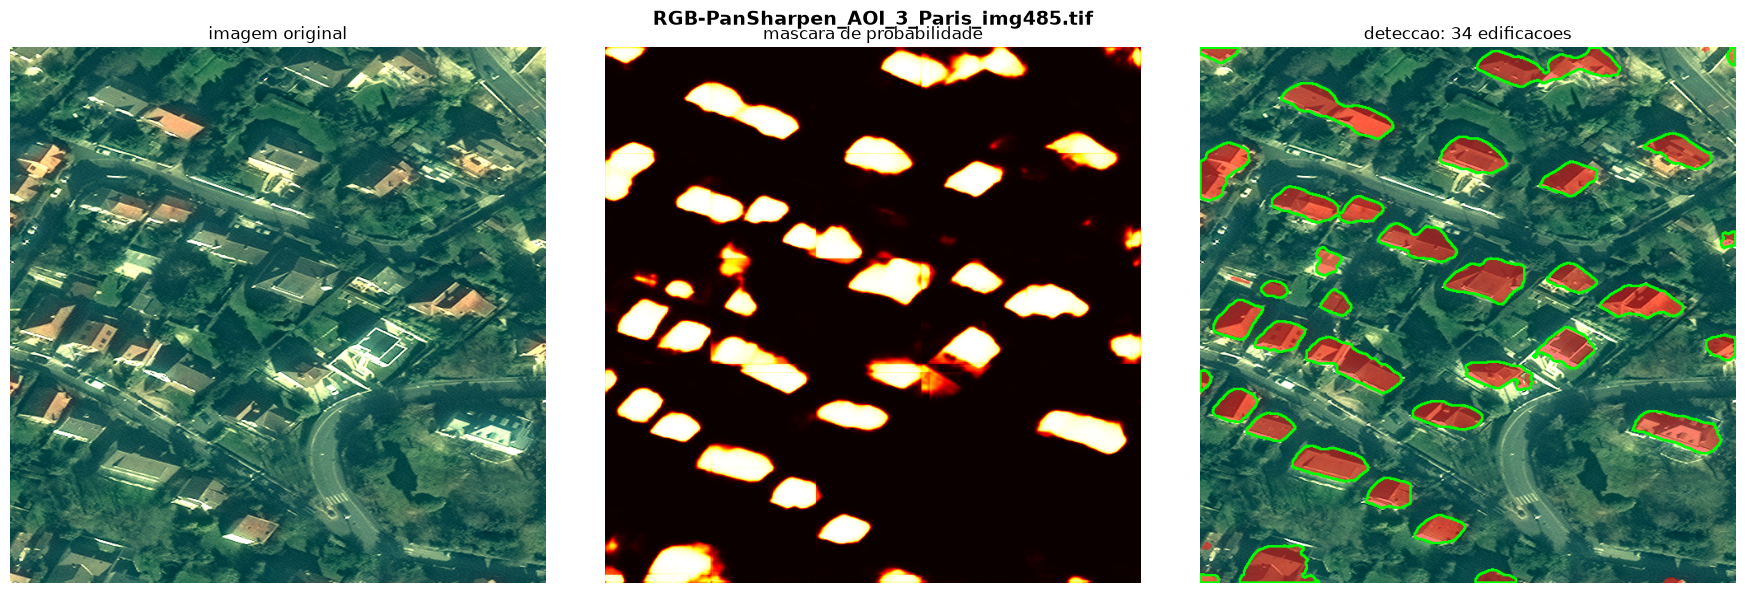

In [42]:
# troque aqui o caminho da imagem
idx = '485'
IMAGE_PATH = f'../data/train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img{idx}.tif'

image = load_image(IMAGE_PATH)
print(f'imagem: {image.shape[1]}x{image.shape[0]} pixels')

mask = predict_image(model, image, patch_size=PATCH_SIZE, stride=128)
contours = extract_contours(mask)
print(f'edificacoes detectadas: {len(contours)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title('imagem original')
axes[0].axis('off')

axes[1].imshow(mask, cmap='hot')
axes[1].set_title('mascara de probabilidade')
axes[1].axis('off')

overlay = image.copy()
binary = (mask > 0.5).astype(np.uint8)
overlay[binary == 1] = overlay[binary == 1] * 0.5 + np.array([1, 0, 0]) * 0.5
cv2.drawContours(overlay, contours, -1, (0, 1, 0), 2)
axes[2].imshow(overlay)
axes[2].set_title(f'deteccao: {len(contours)} edificacoes')
axes[2].axis('off')

plt.suptitle(os.path.basename(IMAGE_PATH), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. teste com imagem externa

tire um print de tela do google maps / google earth em vista de satelite, salve como `.png` ou `.jpg`
e troque o path abaixo. o modelo nunca viu esse tipo de imagem - eh um teste
de generalizacao.

In [43]:
# troque aqui pro path do seu print
# 'C:Users\Cliente\Desktop' -> '/mnt/c/Users/Cliente/Desktop'

MAPS_PATH = '/mnt/c/Users/Cliente/Desktop/teste2.jpg'

imagem: 1183x676 pixels
edificacoes detectadas: 81


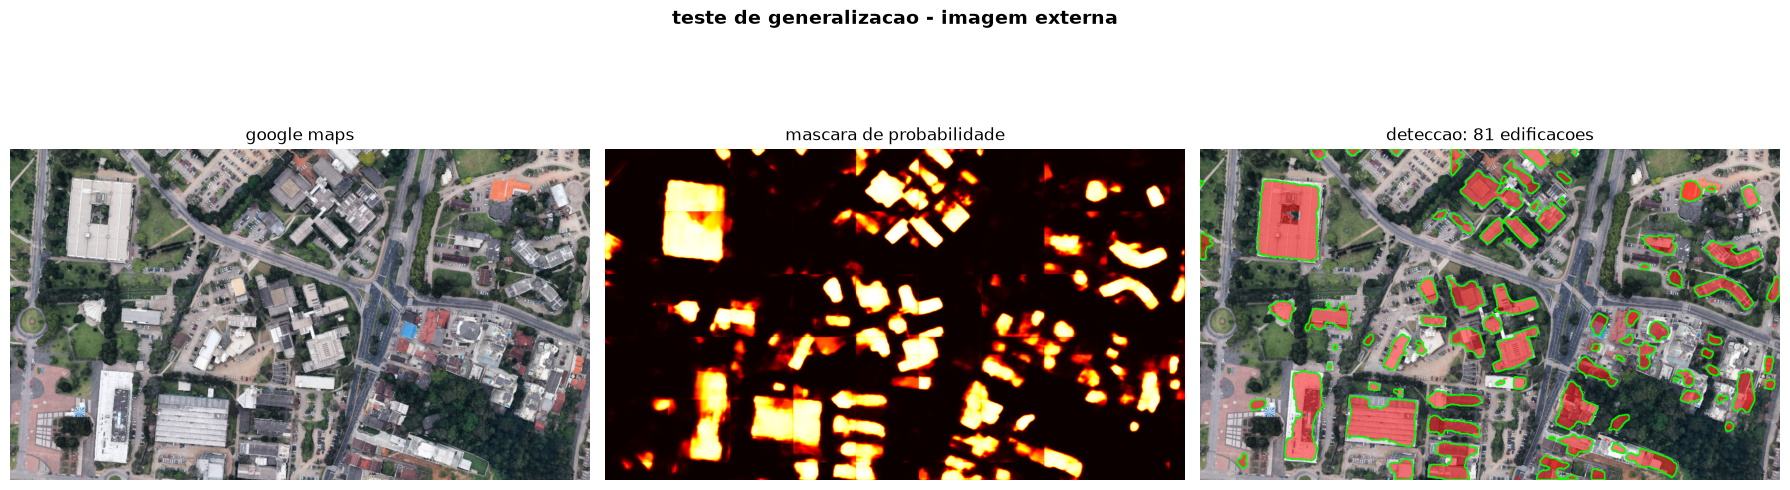

In [44]:
if os.path.exists(MAPS_PATH):
    img_maps = load_image(MAPS_PATH)
    print(f'imagem: {img_maps.shape[1]}x{img_maps.shape[0]} pixels')
    
    mask_maps = predict_image(model, img_maps, patch_size=PATCH_SIZE, stride=128)
    contours_maps = extract_contours(mask_maps, min_area=50)
    print(f'edificacoes detectadas: {len(contours_maps)}')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_maps)
    axes[0].set_title('google maps')
    axes[0].axis('off')
    
    axes[1].imshow(mask_maps, cmap='hot')
    axes[1].set_title('mascara de probabilidade')
    axes[1].axis('off')
    
    overlay_maps = img_maps.copy()
    binary_maps = (mask_maps > 0.5).astype(np.uint8)
    overlay_maps[binary_maps == 1] = overlay_maps[binary_maps == 1] * 0.5 + np.array([1, 0, 0]) * 0.5
    cv2.drawContours(overlay_maps, contours_maps, -1, (0, 1, 0), 2)
    axes[2].imshow(overlay_maps)
    axes[2].set_title(f'deteccao: {len(contours_maps)} edificacoes')
    axes[2].axis('off')
    
    plt.suptitle('teste de generalizacao - imagem externa', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'arquivo nao encontrado: {MAPS_PATH}')
    print('salve um print do google maps e atualize o MAPS_PATH acima.')